# IEQ Extra Trees Fine Tuning

This notebook is an audit trail for the final Extra Trees optimization used in the IEQ paper. It starts from the tuned all-school Extra Trees benchmark model and tests small, interpretable changes one method at a time.

Only Extra Trees is evaluated here, so each experiment answers one question: does this modification improve the selected Extra Trees workflow enough to keep it for the final optimized model?

Macro F1 is the primary metric because the IEQ target is imbalanced. Accuracy, balanced accuracy, and ordinal MAE are reported as supporting diagnostics.

## Experiment Overview

The notebook evaluates the following Extra Trees variants:

1. Recreate the tuned all-school Extra Trees baseline.
2. Add simple operational threshold features for CO2 and temperature.
3. Add imputation-indicator columns for values that were originally missing.
4. Replace nominal three-class classification with a two-threshold ordinal decomposition.
5. Screen class-weight settings and then tune fold-internal probability multipliers.
6. Check complete-case sensor subsets as data-quality sensitivity analyses.
7. Test train-fold-only class balancing.
8. Re-run the strongest retained same-population variant with ten folds.

Every final summary row includes a decision label:

- <span style="color:#0F7B5F; font-weight:700">APPLIED</span>: retained for the final optimized Extra Trees model.
- <span style="color:#B42318; font-weight:700">REJECTED</span>: tested but not retained.
- <span style="color:#4B5563; font-weight:700">REFERENCE</span>: baseline or validation reference, not a proposed modification.

Complete-case filters change the evaluated row population, so they are interpreted as sensitivity checks rather than direct replacements for the main all-row model.

In [1]:
from __future__ import annotations

import builtins
import json
import sys
import time
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, mean_absolute_error, recall_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

STYLE_DIR = Path.cwd()
for root in [Path.cwd(), *Path.cwd().parents]:
    candidate = root / "03_Code" / "ieq_paper" / "01_notebook"
    if (candidate / "paper_style.py").exists():
        STYLE_DIR = candidate.resolve()
        break
if str(STYLE_DIR) not in sys.path:
    sys.path.insert(0, str(STYLE_DIR))

from paper_style import COLORS as PAPER_COLORS, apply_paper_style, plot_confusion_matrix, style_axes

apply_paper_style()
display = getattr(builtins, "display", print)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


In [2]:
SEED = 20260507
N_SPLITS = 5
TEN_FOLD_SPLITS = 10
THRESHOLD_INNER_SPLITS = 3
CALIBRATION_INNER_CV = 3
N_JOBS = 1

TARGET = "IEQ satisfaction 3-class"
DROP_FROM_FEATURES = [TARGET, "TimeVote"]

CLASS_ORDER = ["dissatisfied", "neutral", "satisfied"]
CLASS_TO_NUMBER = {label: i for i, label in enumerate(CLASS_ORDER)}

PRIMARY_METRIC = "macro_f1"
REPORT_METRICS = ["macro_f1", "accuracy", "balanced_accuracy", "ordinal_mae"]

# Set to False when you want a fast notebook check without the heaviest resampling variants.
RUN_SYNTHETIC_SAMPLING = True
RUN_TEN_FOLD_VALIDATION = True

# The final article table reports only the best soft-vote setting, but all weights below are tested deterministically.
SOFT_VOTE_ET_WEIGHTS = [0.80, 0.86, 0.90, 0.95]

DECISION_REFERENCE = "REFERENCE"
DECISION_APPLIED = "APPLIED"
DECISION_REJECTED = "REJECTED"
DECISION_LABELS = {
    DECISION_REFERENCE: "REFERENCE - baseline or validation check",
    DECISION_APPLIED: "APPLIED to final optimized model",
    DECISION_REJECTED: "REJECTED after testing",
}
DECISION_BY_VARIANT = {
    "main_all_school_extra_trees": DECISION_REFERENCE,
    "threshold_flags_co2_1000_t18_t24": DECISION_REJECTED,
    "imputation_indicators": DECISION_APPLIED,
    "ordinal_extra_trees_decomposition": DECISION_REJECTED,
    "ordinal_random_forest_decomposition": DECISION_REJECTED,
    "class_weight_balanced": DECISION_REJECTED,
    "class_weight_equal_1_1_1": DECISION_REJECTED,
    "class_weight_dissatisfied_2_neutral_1_5": DECISION_REJECTED,
    "class_weight_dissatisfied_3_neutral_2": DECISION_APPLIED,
    "class_weight_dissatisfied_4_neutral_2": DECISION_REJECTED,
    "class_weight_dissatisfied_5_neutral_2": DECISION_REJECTED,
    "class_weight_stronger_dissatisfied": DECISION_REJECTED,
    "class_weight_stronger_neutral": DECISION_REJECTED,
    "class_weight_stronger_dissatisfied_neutral": DECISION_REJECTED,
    "best_class_weight_nested_threshold": DECISION_APPLIED,
    "complete_main_ieq_sensors": DECISION_REJECTED,
    "complete_lighting_sound_ttrend": DECISION_REJECTED,
    "random_oversample_to_50pct_majority": DECISION_REJECTED,
    "synthetic_interpolate_to_50pct_majority": DECISION_REJECTED,
    "synthetic_interpolate_to_majority": DECISION_REJECTED,
    "main_all_school_extra_trees_10fold": DECISION_REFERENCE,
    "imputation_indicators_10fold": DECISION_APPLIED,
}

for et_weight in SOFT_VOTE_ET_WEIGHTS:
    rf_weight = 1.0 - et_weight
    DECISION_BY_VARIANT[f"soft_vote_et_{et_weight:.2f}_rf_{rf_weight:.2f}"] = DECISION_REJECTED


## Paths and Data

Load model-ready data for modeling and clean data for missingness checks.


In [3]:
def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for candidate in [start, *start.parents]:
        if (candidate / "02_Datasets").exists() and (candidate / "06_Paper").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing 02_Datasets and 06_Paper.")


PROJECT_ROOT = find_project_root()
DATASET_PATH = PROJECT_ROOT / "02_Datasets" / "model_ready" / "ieq_model_dataset.xlsx"
CLEAN_DATASET_PATH = PROJECT_ROOT / "02_Datasets" / "clean" / "ieq_clean_dataset.xlsx"
BEST_PARAMS_PATH = PROJECT_ROOT / "03_Code" / "ieq_paper" / "02_outputs" / "tables" / "hyperparameter_tuning_best_params.csv"
OUTPUT_DIR = PROJECT_ROOT / "03_Code" / "ieq_paper" / "02_outputs" / "supplementary_experiments" / "tables"
FIGURE_DIR = PROJECT_ROOT / "03_Code" / "ieq_paper" / "02_outputs" / "supplementary_experiments" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

model_data = pd.read_excel(DATASET_PATH)
clean_data = pd.read_excel(CLEAN_DATASET_PATH)

if len(model_data) != len(clean_data):
    raise ValueError("Model-ready and clean datasets must have the same row count for complete-case filters.")

print("Project root:", PROJECT_ROOT)
print("Model-ready data:", model_data.shape)
print("Clean data:", clean_data.shape)

Project root: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism
Model-ready data: (6834, 22)
Clean data: (6834, 27)


In [4]:
feature_columns = [column for column in model_data.columns if column not in DROP_FROM_FEATURES]

X_base = model_data[feature_columns].copy()
y = model_data[TARGET].astype(str)

numeric_features = X_base.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [column for column in X_base.columns if column not in numeric_features]

class_distribution = y.value_counts().reindex(CLASS_ORDER).rename("rows").to_frame()
class_distribution["percent"] = class_distribution["rows"] / len(y) * 100

print("Target:", TARGET)
print("Rows:", len(y))
print("Predictors:", len(feature_columns))
print("Numeric predictors:", numeric_features)
print("Categorical or boolean predictors:", categorical_features)
display(class_distribution)

Target: IEQ satisfaction 3-class
Rows: 6834
Predictors: 20
Numeric predictors: ['Temperature', 'RH', 'CLO', 'CO2', 'Lighting', 'Sound', 'Age', 'EA', 'Ttrend', 'Vote hour']
Categorical or boolean predictors: ['Student', 'Gender', 'LocationBack', 'LocationFront', 'LocationLeft', 'LocationRight', 'LocationMiddle', 'Vote weekday', 'Moment', 'AC on/off']


,rows,percent
IEQ satisfaction 3-class,,
dissatisfied,484,7.082236
neutral,1855,27.143693
satisfied,4495,65.774071


## Tuned Extra Trees and Random Forest Parameters

The notebook starts from the deterministic hyperparameter search in `02_ieq_all_models_hyperparameter_tuning.ipynb`. Extra Trees remains the main model. Random Forest is loaded only for the article-summary checks that explicitly compare a soft vote and an ordinal Random Forest decomposition.


In [5]:
best_params_table = pd.read_csv(BEST_PARAMS_PATH)
best_params = {
    row["model"]: json.loads(row["best_params_json"])
    for _, row in best_params_table.iterrows()
}

EXTRA_TREES_PARAMS = best_params["Extra Trees"]
RANDOM_FOREST_PARAMS = best_params["Random Forest"]

params_for_display = pd.DataFrame(
    [
        {"model": "Extra Trees", **EXTRA_TREES_PARAMS},
        {"model": "Random Forest", **RANDOM_FOREST_PARAMS},
    ]
)
display(params_for_display)


,model,model__bootstrap,model__class_weight,model__criterion,model__max_depth,model__max_features,model__max_samples,model__min_samples_leaf,model__min_samples_split,model__n_estimators
0,Extra Trees,True,balanced,entropy,None,None,0.9,2,10,500
1,Random Forest,NaN,balanced_subsample,gini,None,sqrt,NaN,4,10,300


## Shared Validation and Reporting Functions

All variants use stratified cross-validation with the same seed. Numeric scaling and categorical encoding are fitted inside each training fold, so validation rows never influence preprocessing.

The helper functions also attach the decision labels used throughout the notebook. Green rows are retained for the final optimized model, red rows were tested and rejected, and gray rows are references.

In [6]:
def dense_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    numeric = X.select_dtypes(include=["number"]).columns.tolist()
    categorical = [column for column in X.columns if column not in numeric]
    transformers = []
    if numeric:
        transformers.append(("numeric", StandardScaler(), numeric))
    if categorical:
        transformers.append(("categorical", dense_one_hot_encoder(), categorical))
    return ColumnTransformer(transformers=transformers)


def make_model(model_name: str, seed: int) -> ExtraTreesClassifier | RandomForestClassifier:
    if model_name == "Extra Trees":
        return ExtraTreesClassifier(n_jobs=N_JOBS, random_state=seed)
    if model_name == "Random Forest":
        return RandomForestClassifier(n_jobs=N_JOBS, random_state=seed)
    raise ValueError(f"Unsupported model for this notebook: {model_name}")


def make_pipeline(X: pd.DataFrame, model_name: str, params: dict, seed: int) -> Pipeline:
    pipeline = Pipeline(
        steps=[
            ("preprocess", make_preprocessor(X)),
            ("model", make_model(model_name, seed)),
        ]
    )
    pipeline.set_params(**params)
    return pipeline


def ordinal_mae(y_true: pd.Series, y_pred: pd.Series | np.ndarray) -> float:
    true_values = pd.Series(y_true).map(CLASS_TO_NUMBER).to_numpy()
    pred_values = pd.Series(y_pred).map(CLASS_TO_NUMBER).to_numpy()
    return float(mean_absolute_error(true_values, pred_values))


def metric_row(y_true: pd.Series, y_pred: pd.Series | np.ndarray) -> dict[str, float]:
    return {
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "ordinal_mae": ordinal_mae(y_true, y_pred),
    }


def add_decision_columns(table: pd.DataFrame) -> pd.DataFrame:
    output = table.copy()
    output["decision"] = output["variant"].map(DECISION_BY_VARIANT).fillna(DECISION_REJECTED)
    output["decision_label"] = output["decision"].map(DECISION_LABELS)
    return output


def style_decision_table(table: pd.DataFrame):
    color_by_decision = {
        DECISION_APPLIED: f"background-color: {PAPER_COLORS['best']}33; color: {PAPER_COLORS['best']}; font-weight: 700",
        DECISION_REJECTED: f"background-color: {PAPER_COLORS['low']}33; color: {PAPER_COLORS['low']}; font-weight: 700",
        DECISION_REFERENCE: f"background-color: {PAPER_COLORS['neutral']}22; color: {PAPER_COLORS['neutral']}; font-weight: 700",
    }

    def style_row(row: pd.Series) -> list[str]:
        decision = row.get("decision", "")
        if not decision and str(row.get("decision_label", "")).startswith(DECISION_APPLIED):
            decision = DECISION_APPLIED
        elif not decision and str(row.get("decision_label", "")).startswith(DECISION_REJECTED):
            decision = DECISION_REJECTED
        elif not decision and str(row.get("decision_label", "")).startswith(DECISION_REFERENCE):
            decision = DECISION_REFERENCE
        style = color_by_decision.get(decision, "")
        return [style if column in {"decision", "decision_label"} else "" for column in row.index]

    return table.style.apply(style_row, axis=1)


def class_ordered_probabilities(pipeline: Pipeline, X: pd.DataFrame) -> np.ndarray:
    raw_probabilities = pipeline.predict_proba(X)
    output = np.zeros((len(X), len(CLASS_ORDER)))
    class_to_column = {label: index for index, label in enumerate(pipeline.named_steps["model"].classes_)}
    for output_column, label in enumerate(CLASS_ORDER):
        if label in class_to_column:
            output[:, output_column] = raw_probabilities[:, class_to_column[label]]
    return output


In [7]:
SamplingFunction = Callable[[pd.DataFrame, pd.Series, int], tuple[pd.DataFrame, pd.Series]]


def evaluate_cv_variant(
    experiment: str,
    variant: str,
    X: pd.DataFrame,
    y_values: pd.Series,
    *,
    model_name: str = "Extra Trees",
    params: dict | None = None,
    sampling_fn: SamplingFunction | None = None,
    note: str = "",
    n_splits: int | None = None,
) -> pd.DataFrame:
    n_splits = N_SPLITS if n_splits is None else n_splits
    params = EXTRA_TREES_PARAMS if params is None else params
    rows = []
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    for fold, (train_index, test_index) in enumerate(cv.split(X, y_values), start=1):
        X_train, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
        y_train, y_test = y_values.iloc[train_index].copy(), y_values.iloc[test_index].copy()

        if sampling_fn is not None:
            X_train, y_train = sampling_fn(X_train, y_train, fold)

        pipeline = make_pipeline(X, model_name=model_name, params=params, seed=SEED + fold)

        start = time.perf_counter()
        pipeline.fit(X_train, y_train)
        fit_seconds = time.perf_counter() - start

        start = time.perf_counter()
        y_pred = pd.Series(pipeline.predict(X_test), index=y_test.index)
        predict_seconds = time.perf_counter() - start

        rows.append(
            {
                "experiment": experiment,
                "variant": variant,
                "fold": fold,
                "cv_splits": n_splits,
                "model": model_name,
                "rows": len(X),
                "train_rows_after_sampling": len(X_train),
                "predictors": X.shape[1],
                "fit_seconds": fit_seconds,
                "predict_seconds": predict_seconds,
                "total_seconds": fit_seconds + predict_seconds,
                "note": note,
                **metric_row(y_test, y_pred),
            }
        )

    return pd.DataFrame(rows)


def summarize_folds(folds: pd.DataFrame) -> pd.DataFrame:
    group_columns = ["experiment", "variant", "cv_splits", "model", "rows", "predictors", "note"]
    metric_columns = REPORT_METRICS + ["fit_seconds", "predict_seconds", "total_seconds", "train_rows_after_sampling"]
    summary = folds.groupby(group_columns, dropna=False)[metric_columns].agg(["mean", "std"]).reset_index()
    summary.columns = [
        "_".join(column).rstrip("_") if isinstance(column, tuple) else column
        for column in summary.columns
    ]
    return summary


def result_table(summary: pd.DataFrame) -> pd.DataFrame:
    columns = [
        "variant",
        "cv_splits",
        "rows",
        "predictors",
        "macro_f1_mean",
        "accuracy_mean",
        "balanced_accuracy_mean",
        "ordinal_mae_mean",
    ]
    table = summary[columns].copy()
    for column in table.select_dtypes(include=["float"]).columns:
        table[column] = table[column].round(6)
    return table


def metric_change_table(
    summary: pd.DataFrame,
    baseline_summary: pd.DataFrame,
    baseline_variant: str = "main_all_school_extra_trees",
) -> pd.DataFrame:
    baseline = baseline_summary[baseline_summary["variant"].eq(baseline_variant)].iloc[0]
    rows = []
    for _, row in summary.iterrows():
        rows.append(
            {
                "variant": row["variant"],
                "same_population_as_main": bool(row["rows"] == baseline["rows"]),
                "macro_f1_delta": row["macro_f1_mean"] - baseline["macro_f1_mean"],
                "accuracy_delta": row["accuracy_mean"] - baseline["accuracy_mean"],
                "balanced_accuracy_delta": row["balanced_accuracy_mean"] - baseline["balanced_accuracy_mean"],
                "ordinal_mae_delta": row["ordinal_mae_mean"] - baseline["ordinal_mae_mean"],
            }
        )
    table = pd.DataFrame(rows)
    for column in table.select_dtypes(include=["float"]).columns:
        table[column] = table[column].round(6)
    return table

## 1. Main Extra Trees Baseline

This step re-evaluates the tuned Extra Trees model selected in the benchmark comparison. It is the reference point for all later deltas.

Decision: <span style="color:#4B5563; font-weight:700">REFERENCE</span>. This is not an optimization; it is the comparison baseline.

In [8]:
baseline_folds = evaluate_cv_variant(
    "baseline",
    "main_all_school_extra_trees",
    X_base,
    y,
    note="Tuned Extra Trees on the full imputed all-school dataset.",
)

baseline_summary = summarize_folds(baseline_folds)

display(result_table(baseline_summary))

,variant,cv_splits,rows,predictors,macro_f1_mean,accuracy_mean,balanced_accuracy_mean,ordinal_mae_mean
0,main_all_school_extra_trees,5,6834,20,0.592314,0.723294,0.593757,0.313725


## 2. Manual Threshold Features

This test adds three simple operational flags: CO2 > 1000 ppm, Temperature < 18 deg C, and Temperature > 24 deg C. The goal is to check whether explicit comfort-threshold indicators help Extra Trees beyond the continuous sensor values.

Decision: <span style="color:#B42318; font-weight:700">REJECTED</span>. The threshold flags are reported as a tested feature-engineering idea, but they are not retained in the final optimized model.

In [9]:
def add_threshold_features(frame: pd.DataFrame) -> pd.DataFrame:
    output = frame.copy()
    output["CO2_gt_1000ppm"] = output["CO2"].gt(1000.0).astype(int)
    output["Temperature_lt_18C"] = output["Temperature"].lt(18.0).astype(int)
    output["Temperature_gt_24C"] = output["Temperature"].gt(24.0).astype(int)
    return output


X_threshold = add_threshold_features(X_base)

threshold_folds = evaluate_cv_variant(
    "feature_engineering",
    "threshold_flags_co2_1000_t18_t24",
    X_threshold,
    y,
    note="Adds binary CO2 and temperature threshold indicators.",
)

threshold_summary = summarize_folds(threshold_folds)

print("Metric values")
display(result_table(threshold_summary))
print("Change relative to main Extra Trees baseline")
display(metric_change_table(threshold_summary, baseline_summary))

Metric values


,variant,cv_splits,rows,predictors,macro_f1_mean,accuracy_mean,balanced_accuracy_mean,ordinal_mae_mean
0,threshold_flags_co2_1000_t18_t24,5,6834,23,0.586357,0.718758,0.587964,0.319286


Change relative to main Extra Trees baseline


,variant,same_population_as_main,macro_f1_delta,accuracy_delta,balanced_accuracy_delta,ordinal_mae_delta
0,threshold_flags_co2_1000_t18_t24,True,-0.005957,-0.004536,-0.005792,0.005561


## 3. Imputation Indicators

This test adds binary columns showing which predictors were originally missing before imputation. The imputed values remain in the dataset, but the model also receives information about where imputation occurred.

Decision: <span style="color:#0F7B5F; font-weight:700">APPLIED</span>. This same-population variant is retained for the final optimized Extra Trees workflow.

In [10]:
def add_missingness_indicators(frame: pd.DataFrame, clean_frame: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    output = frame.copy()
    indicator_columns = []

    for column in frame.columns:
        if column not in clean_frame.columns:
            continue
        missing_mask = clean_frame[column].isna()
        if not missing_mask.any():
            continue
        indicator = f"{column}_was_imputed"
        output[indicator] = missing_mask.astype(int).to_numpy()
        indicator_columns.append(indicator)

    if indicator_columns:
        output["n_imputed_predictors"] = output[indicator_columns].sum(axis=1)
        indicator_columns.append("n_imputed_predictors")

    return output, indicator_columns


X_missingness, missingness_indicator_columns = add_missingness_indicators(X_base, clean_data)

print("Added missingness indicators:")
display(pd.Series(missingness_indicator_columns, name="indicator").to_frame())

missingness_folds = evaluate_cv_variant(
    "missingness_indicators",
    "imputation_indicators",
    X_missingness,
    y,
    note="Adds binary flags for predictors that were missing before imputation, plus a per-row missingness count.",
)

missingness_summary = summarize_folds(missingness_folds)

print("Metric values")
display(result_table(missingness_summary))
print("Change relative to main Extra Trees baseline")
display(metric_change_table(missingness_summary, baseline_summary))

Added missingness indicators:


,indicator
0,CLO_was_imputed
1,Lighting_was_imputed
2,Sound_was_imputed
3,Age_was_imputed
4,Gender_was_imputed
5,LocationBack_was_imputed
6,LocationFront_was_imputed
7,LocationLeft_was_imputed
8,LocationMiddle_was_imputed
9,Ttrend_was_imputed


Metric values


,variant,cv_splits,rows,predictors,macro_f1_mean,accuracy_mean,balanced_accuracy_mean,ordinal_mae_mean
0,imputation_indicators,5,6834,31,0.603851,0.730172,0.605905,0.306555


Change relative to main Extra Trees baseline


,variant,same_population_as_main,macro_f1_delta,accuracy_delta,balanced_accuracy_delta,ordinal_mae_delta
0,imputation_indicators,True,0.011537,0.006877,0.012148,-0.00717


## 4. Soft-Vote Extra Trees + Random Forest Check

This section tests whether a small Random Forest contribution improves the tuned Extra Trees probabilities. Each fold fits one Extra Trees model and one Random Forest model on the same training split, then combines their predicted class probabilities with predefined weights.

Decision: <span style="color:#B42318; font-weight:700">REJECTED</span>. The best soft-vote row is still reported in the final article table, but the final optimized model stays as a single Extra Trees model.


In [11]:
def evaluate_soft_vote_weights(
    X: pd.DataFrame,
    y_values: pd.Series,
    et_weights: list[float],
) -> pd.DataFrame:
    rows = []
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    for fold, (train_index, test_index) in enumerate(cv.split(X, y_values), start=1):
        X_train, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
        y_train, y_test = y_values.iloc[train_index].copy(), y_values.iloc[test_index].copy()

        et_pipeline = make_pipeline(X, "Extra Trees", EXTRA_TREES_PARAMS, SEED + fold)
        rf_pipeline = make_pipeline(X, "Random Forest", RANDOM_FOREST_PARAMS, SEED + 1000 + fold)

        start = time.perf_counter()
        et_pipeline.fit(X_train, y_train)
        rf_pipeline.fit(X_train, y_train)
        fit_seconds = time.perf_counter() - start

        start = time.perf_counter()
        et_probabilities = class_ordered_probabilities(et_pipeline, X_test)
        rf_probabilities = class_ordered_probabilities(rf_pipeline, X_test)
        predict_seconds = time.perf_counter() - start

        for et_weight in et_weights:
            rf_weight = 1.0 - et_weight
            combined_probabilities = (et_weight * et_probabilities) + (rf_weight * rf_probabilities)
            y_pred = pd.Series(
                [CLASS_ORDER[index] for index in np.argmax(combined_probabilities, axis=1)],
                index=y_test.index,
            )
            variant = f"soft_vote_et_{et_weight:.2f}_rf_{rf_weight:.2f}"
            rows.append(
                {
                    "experiment": "soft_vote_extra_trees_random_forest",
                    "variant": variant,
                    "fold": fold,
                    "cv_splits": N_SPLITS,
                    "model": "Extra Trees + Random Forest",
                    "rows": len(X),
                    "train_rows_after_sampling": len(X_train),
                    "predictors": X.shape[1],
                    "fit_seconds": fit_seconds,
                    "predict_seconds": predict_seconds,
                    "total_seconds": fit_seconds + predict_seconds,
                    "note": f"Fold-internal probability soft vote with ET weight {et_weight:.2f} and RF weight {rf_weight:.2f}.",
                    **metric_row(y_test, y_pred),
                }
            )

    return pd.DataFrame(rows)


soft_vote_folds = evaluate_soft_vote_weights(X_base, y, SOFT_VOTE_ET_WEIGHTS)
soft_vote_summary = summarize_folds(soft_vote_folds).sort_values(["macro_f1_mean", "accuracy_mean"], ascending=[False, False]).reset_index(drop=True)
soft_vote_comparison = pd.concat([baseline_summary, soft_vote_summary], ignore_index=True)
soft_vote_baseline_row = soft_vote_comparison[soft_vote_comparison["variant"].eq("main_all_school_extra_trees")].iloc[0]
for metric in REPORT_METRICS:
    soft_vote_comparison[f"{metric}_delta_vs_main"] = soft_vote_comparison[f"{metric}_mean"] - soft_vote_baseline_row[f"{metric}_mean"]
soft_vote_comparison["same_population_as_main"] = soft_vote_comparison["rows"].eq(int(soft_vote_baseline_row["rows"]))
soft_vote_comparison = add_decision_columns(soft_vote_comparison)

soft_vote_table = soft_vote_comparison[
    [
        "variant",
        "decision_label",
        "model",
        "cv_splits",
        "rows",
        "predictors",
        "same_population_as_main",
        "macro_f1_mean",
        "macro_f1_delta_vs_main",
        "accuracy_mean",
        "accuracy_delta_vs_main",
        "balanced_accuracy_mean",
        "balanced_accuracy_delta_vs_main",
        "ordinal_mae_mean",
        "ordinal_mae_delta_vs_main",
    ]
].copy()
for column in soft_vote_table.select_dtypes(include=["float"]).columns:
    soft_vote_table[column] = soft_vote_table[column].round(6)

print("Soft-vote Extra Trees + Random Forest comparison")
display(style_decision_table(soft_vote_table))

soft_vote_folds_path = OUTPUT_DIR / "ieq_soft_vote_extra_trees_random_forest_folds.csv"
soft_vote_summary_path = OUTPUT_DIR / "ieq_soft_vote_extra_trees_random_forest_summary.csv"
soft_vote_comparison_path = OUTPUT_DIR / "ieq_soft_vote_extra_trees_random_forest_comparison.csv"
soft_vote_folds.to_csv(soft_vote_folds_path, index=False)
soft_vote_summary.to_csv(soft_vote_summary_path, index=False)
soft_vote_table.to_csv(soft_vote_comparison_path, index=False)

print("Saved soft-vote fold results to:", soft_vote_folds_path)
print("Saved soft-vote comparison to:", soft_vote_comparison_path)


Soft-vote Extra Trees + Random Forest comparison


,variant,decision_label,model,cv_splits,rows,predictors,same_population_as_main,macro_f1_mean,macro_f1_delta_vs_main,accuracy_mean,accuracy_delta_vs_main,balanced_accuracy_mean,balanced_accuracy_delta_vs_main,ordinal_mae_mean,ordinal_mae_delta_vs_main
0,main_all_school_extra_trees,REFERENCE - baseline or validation check,Extra Trees,5,6834,20,True,0.592314,0.000000,0.723294,0.000000,0.593757,0.000000,0.313725,0.000000
1,soft_vote_et_0.80_rf_0.20,REJECTED after testing,Extra Trees + Random Forest,5,6834,20,True,0.593842,0.001528,0.724465,0.001171,0.594970,0.001214,0.313286,-0.000439
2,soft_vote_et_0.90_rf_0.10,REJECTED after testing,Extra Trees + Random Forest,5,6834,20,True,0.593345,0.001031,0.723880,0.000586,0.594146,0.000389,0.313286,-0.000439
3,soft_vote_et_0.86_rf_0.14,REJECTED after testing,Extra Trees + Random Forest,5,6834,20,True,0.593338,0.001024,0.724465,0.001171,0.594040,0.000284,0.313139,-0.000586
4,soft_vote_et_0.95_rf_0.05,REJECTED after testing,Extra Trees + Random Forest,5,6834,20,True,0.592818,0.000504,0.723587,0.000293,0.593701,-0.000056,0.313579,-0.000147


Saved soft-vote fold results to: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\supplementary_experiments\tables\ieq_soft_vote_extra_trees_random_forest_folds.csv
Saved soft-vote comparison to: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\supplementary_experiments\tables\ieq_soft_vote_extra_trees_random_forest_comparison.csv


## 5. Ordinal Classification

The target has a natural order: dissatisfied < neutral < satisfied. This section tests whether two binary threshold models can improve the ordinary three-class classifier.

Both Extra Trees and Random Forest are tested with the same deterministic five-fold splits:

1. IEQ satisfaction > dissatisfied,
2. IEQ satisfaction > neutral.

The two probabilities are reconstructed into the original three classes. The final article table keeps one row for the Extra Trees ordinal decomposition and one row for the Random Forest ordinal decomposition.

Decision: <span style="color:#B42318; font-weight:700">REJECTED</span>. The ordinal variants are reported as tested alternatives, but they are not applied to the final optimized model.


Ordinal decomposition comparison


,variant,decision_label,model,cv_splits,rows,predictors,same_population_as_main,macro_f1_mean,macro_f1_delta_vs_main,accuracy_mean,accuracy_delta_vs_main,balanced_accuracy_mean,balanced_accuracy_delta_vs_main,ordinal_mae_mean,ordinal_mae_delta_vs_main
0,main_all_school_extra_trees,REFERENCE - baseline or validation check,Extra Trees,5,6834,20,True,0.592314,0.000000,0.723294,0.000000,0.593757,0.000000,0.313725,0.000000
1,ordinal_extra_trees_decomposition,REJECTED after testing,Extra Trees,5,6834,20,True,0.586104,-0.006210,0.730025,0.006731,0.585288,-0.008469,0.310798,-0.002927
2,ordinal_random_forest_decomposition,REJECTED after testing,Random Forest,5,6834,20,True,0.548013,-0.044301,0.711882,-0.011412,0.553920,-0.039837,0.336550,0.022825


Best ordinal variant by macro F1: ordinal_extra_trees_decomposition


,dissatisfied,neutral,satisfied
dissatisfied,215,106,163
neutral,211,789,855
satisfied,116,394,3985


Saved ordinal confusion figure to: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\supplementary_experiments\figures\ieq_ordinal_classification_best_confusion_matrix.png


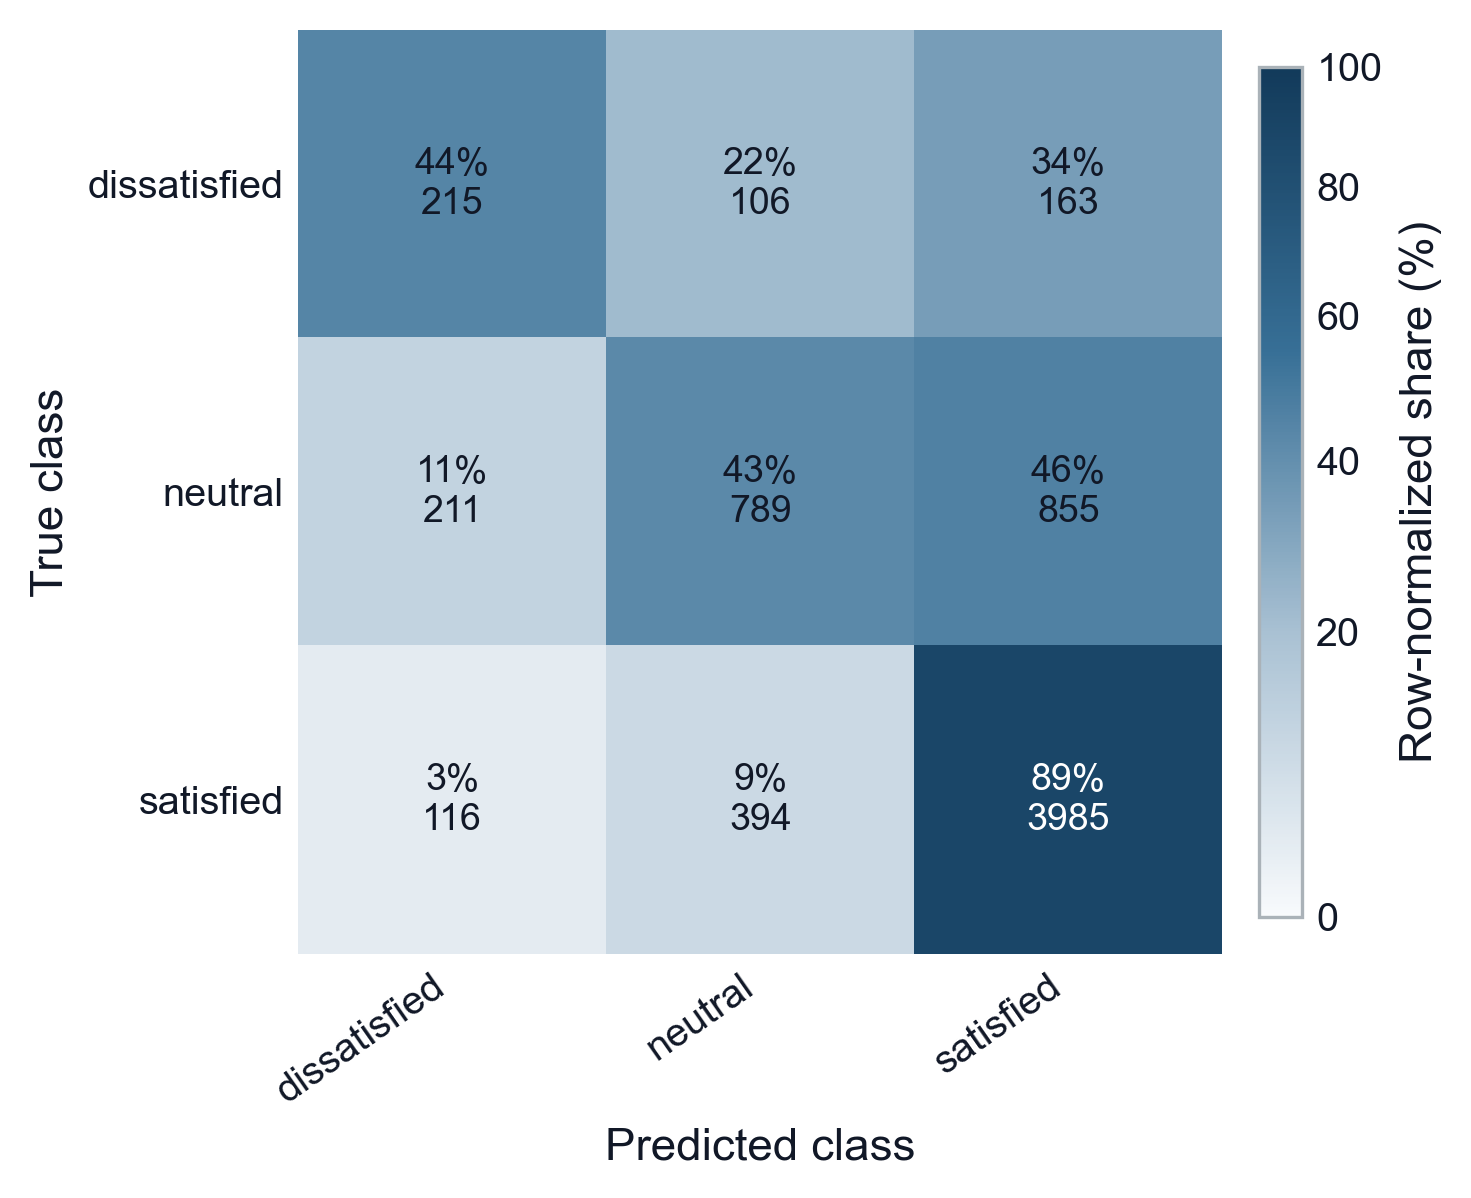

In [12]:
def positive_class_probability(pipeline: Pipeline, X: pd.DataFrame) -> np.ndarray:
    raw_probabilities = pipeline.predict_proba(X)
    classes = list(pipeline.named_steps["model"].classes_)
    if True not in classes:
        return np.zeros(len(X))
    return raw_probabilities[:, classes.index(True)]


def reconstruct_ordinal_probabilities(
    probability_gt_dissatisfied: np.ndarray,
    probability_gt_neutral: np.ndarray,
) -> np.ndarray:
    p_gt_dissatisfied = np.clip(probability_gt_dissatisfied, 0.0, 1.0)
    p_gt_neutral = np.clip(probability_gt_neutral, 0.0, 1.0)
    p_gt_neutral = np.minimum(p_gt_neutral, p_gt_dissatisfied)

    probabilities = np.column_stack(
        [
            1.0 - p_gt_dissatisfied,
            p_gt_dissatisfied - p_gt_neutral,
            p_gt_neutral,
        ]
    )
    probabilities = np.clip(probabilities, 0.0, 1.0)
    row_sums = probabilities.sum(axis=1, keepdims=True)
    return probabilities / np.where(row_sums == 0.0, 1.0, row_sums)


def evaluate_ordinal_decomposition(
    X: pd.DataFrame,
    y_values: pd.Series,
    *,
    model_name: str,
    params: dict,
    variant: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    predictions = []
    y_numeric = y_values.map(CLASS_TO_NUMBER)
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    for fold, (train_index, test_index) in enumerate(cv.split(X, y_values), start=1):
        X_train, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
        y_train, y_test = y_values.iloc[train_index].copy(), y_values.iloc[test_index].copy()
        y_train_numeric = y_numeric.iloc[train_index]

        gt_dissatisfied_pipeline = make_pipeline(X, model_name, params, SEED + fold)
        gt_neutral_pipeline = make_pipeline(X, model_name, params, SEED + 100 + fold)

        start = time.perf_counter()
        gt_dissatisfied_pipeline.fit(X_train, y_train_numeric.gt(CLASS_TO_NUMBER["dissatisfied"]))
        gt_neutral_pipeline.fit(X_train, y_train_numeric.gt(CLASS_TO_NUMBER["neutral"]))
        fit_seconds = time.perf_counter() - start

        start = time.perf_counter()
        p_gt_dissatisfied = positive_class_probability(gt_dissatisfied_pipeline, X_test)
        p_gt_neutral = positive_class_probability(gt_neutral_pipeline, X_test)
        class_probabilities = reconstruct_ordinal_probabilities(p_gt_dissatisfied, p_gt_neutral)
        y_pred = pd.Series(
            [CLASS_ORDER[index] for index in np.argmax(class_probabilities, axis=1)],
            index=y_test.index,
        )
        predict_seconds = time.perf_counter() - start

        rows.append(
            {
                "experiment": "ordinal_classification",
                "variant": variant,
                "fold": fold,
                "cv_splits": N_SPLITS,
                "model": model_name,
                "rows": len(X),
                "train_rows_after_sampling": len(X_train),
                "predictors": X.shape[1],
                "fit_seconds": fit_seconds,
                "predict_seconds": predict_seconds,
                "total_seconds": fit_seconds + predict_seconds,
                "note": f"Two-threshold ordinal decomposition with fold-internal {model_name} binary classifiers.",
                **metric_row(y_test, y_pred),
            }
        )

        predictions.append(
            pd.DataFrame(
                {
                    "variant": variant,
                    "fold": fold,
                    "row_id": y_test.index,
                    "y_true": y_test.to_numpy(),
                    "y_pred": y_pred.to_numpy(),
                    "prob_dissatisfied": class_probabilities[:, 0],
                    "prob_neutral": class_probabilities[:, 1],
                    "prob_satisfied": class_probabilities[:, 2],
                    "prob_y_gt_dissatisfied": p_gt_dissatisfied,
                    "prob_y_gt_neutral": p_gt_neutral,
                }
            )
        )

    return pd.DataFrame(rows), pd.concat(predictions, ignore_index=True)


ordinal_specs = [
    ("Extra Trees", EXTRA_TREES_PARAMS, "ordinal_extra_trees_decomposition"),
    ("Random Forest", RANDOM_FOREST_PARAMS, "ordinal_random_forest_decomposition"),
]
ordinal_fold_parts = []
ordinal_prediction_parts = []
for model_name, params, variant in ordinal_specs:
    fold_part, prediction_part = evaluate_ordinal_decomposition(
        X_base,
        y,
        model_name=model_name,
        params=params,
        variant=variant,
    )
    ordinal_fold_parts.append(fold_part)
    ordinal_prediction_parts.append(prediction_part)

ordinal_folds = pd.concat(ordinal_fold_parts, ignore_index=True)
ordinal_predictions = pd.concat(ordinal_prediction_parts, ignore_index=True)
ordinal_summary = summarize_folds(ordinal_folds).sort_values(["macro_f1_mean", "accuracy_mean"], ascending=[False, False]).reset_index(drop=True)

ordinal_comparison = pd.concat([baseline_summary, ordinal_summary], ignore_index=True)
ordinal_baseline_row = ordinal_comparison[ordinal_comparison["variant"].eq("main_all_school_extra_trees")].iloc[0]
for metric in REPORT_METRICS:
    ordinal_comparison[f"{metric}_delta_vs_main"] = ordinal_comparison[f"{metric}_mean"] - ordinal_baseline_row[f"{metric}_mean"]
ordinal_comparison["same_population_as_main"] = ordinal_comparison["rows"].eq(int(ordinal_baseline_row["rows"]))
ordinal_comparison = add_decision_columns(ordinal_comparison)

ordinal_comparison_table = ordinal_comparison[
    [
        "variant",
        "decision_label",
        "model",
        "cv_splits",
        "rows",
        "predictors",
        "same_population_as_main",
        "macro_f1_mean",
        "macro_f1_delta_vs_main",
        "accuracy_mean",
        "accuracy_delta_vs_main",
        "balanced_accuracy_mean",
        "balanced_accuracy_delta_vs_main",
        "ordinal_mae_mean",
        "ordinal_mae_delta_vs_main",
    ]
].copy()

for column in ordinal_comparison_table.select_dtypes(include=["float"]).columns:
    ordinal_comparison_table[column] = ordinal_comparison_table[column].round(6)

print("Ordinal decomposition comparison")
display(style_decision_table(ordinal_comparison_table))

best_ordinal_variant = ordinal_summary.iloc[0]["variant"]
best_ordinal_predictions = ordinal_predictions[ordinal_predictions["variant"].eq(best_ordinal_variant)].copy()
best_ordinal_confusion = pd.DataFrame(
    confusion_matrix(best_ordinal_predictions["y_true"], best_ordinal_predictions["y_pred"], labels=CLASS_ORDER),
    index=CLASS_ORDER,
    columns=CLASS_ORDER,
)

print("Best ordinal variant by macro F1:", best_ordinal_variant)
display(best_ordinal_confusion)

ordinal_folds_path = OUTPUT_DIR / "ieq_ordinal_classification_folds.csv"
ordinal_predictions_path = OUTPUT_DIR / "ieq_ordinal_classification_predictions.csv"
ordinal_summary_path = OUTPUT_DIR / "ieq_ordinal_classification_summary.csv"
ordinal_comparison_path = OUTPUT_DIR / "ieq_ordinal_classification_comparison.csv"
ordinal_confusion_path = OUTPUT_DIR / "ieq_ordinal_classification_best_confusion_matrix.csv"

ordinal_folds.to_csv(ordinal_folds_path, index=False)
ordinal_predictions.to_csv(ordinal_predictions_path, index=False)
ordinal_summary.to_csv(ordinal_summary_path, index=False)
ordinal_comparison_table.to_csv(ordinal_comparison_path, index=False)
best_ordinal_confusion.to_csv(ordinal_confusion_path)


fig, ax = plt.subplots(figsize=(4.8, 4.2), constrained_layout=True)
image, colorbar_label = plot_confusion_matrix(
    ax,
    best_ordinal_confusion,
    labels=CLASS_ORDER,
    display_labels=CLASS_ORDER,
    title=None,
    xtick_rotation=35,
    annotation_fontsize=9,
)
colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label(colorbar_label)
ordinal_confusion_figure_path = FIGURE_DIR / "ieq_ordinal_classification_best_confusion_matrix.png"
fig.savefig(ordinal_confusion_figure_path, dpi=300, bbox_inches="tight")
print("Saved ordinal confusion figure to:", ordinal_confusion_figure_path)
plt.show()


## 6. Class-Weight and Threshold Tuning

This section has two parts. First, several Extra Trees class-weight settings are screened. Second, the best class-weight setting is combined with nested fold-internal probability-multiplier tuning.

Decision: <span style="color:#0F7B5F; font-weight:700">APPLIED</span> only for the selected class-weight plus nested threshold variant. Other screened class-weight variants are <span style="color:#B42318; font-weight:700">REJECTED</span>.


In [13]:
RECALL_COLUMNS = [f"recall_{label}" for label in CLASS_ORDER]


def class_weight_from_numeric(numeric_weights: dict[int, float]) -> dict[str, float]:
    return {CLASS_ORDER[class_number]: weight for class_number, weight in numeric_weights.items()}


CLASS_WEIGHT_SPECS = [
    {
        "variant": "class_weight_balanced",
        "class_weight": "balanced",
        "description": "Baseline Extra Trees balanced class weights.",
    },
    {
        "variant": "class_weight_equal_1_1_1",
        "class_weight": class_weight_from_numeric({0: 1, 1: 1, 2: 1}),
        "description": "Manual equal class weights: {0: 1, 1: 1, 2: 1}.",
    },
    {
        "variant": "class_weight_dissatisfied_2_neutral_1_5",
        "class_weight": class_weight_from_numeric({0: 2, 1: 1.5, 2: 1}),
        "description": "Manual class weights: {0: 2, 1: 1.5, 2: 1}.",
    },
    {
        "variant": "class_weight_dissatisfied_3_neutral_2",
        "class_weight": class_weight_from_numeric({0: 3, 1: 2, 2: 1}),
        "description": "Manual class weights: {0: 3, 1: 2, 2: 1}.",
    },
    {
        "variant": "class_weight_dissatisfied_4_neutral_2",
        "class_weight": class_weight_from_numeric({0: 4, 1: 2, 2: 1}),
        "description": "Manual class weights: {0: 4, 1: 2, 2: 1}.",
    },
    {
        "variant": "class_weight_dissatisfied_5_neutral_2",
        "class_weight": class_weight_from_numeric({0: 5, 1: 2, 2: 1}),
        "description": "Manual class weights: {0: 5, 1: 2, 2: 1}.",
    },
    {
        "variant": "class_weight_stronger_dissatisfied",
        "class_weight": class_weight_from_numeric({0: 4, 1: 1, 2: 1}),
        "description": "Stronger dissatisfied weight only.",
    },
    {
        "variant": "class_weight_stronger_neutral",
        "class_weight": class_weight_from_numeric({0: 1, 1: 2.5, 2: 1}),
        "description": "Stronger neutral weight only.",
    },
    {
        "variant": "class_weight_stronger_dissatisfied_neutral",
        "class_weight": class_weight_from_numeric({0: 4, 1: 2.5, 2: 1}),
        "description": "Stronger dissatisfied and neutral weights.",
    },
]

CLASS_WEIGHT_SPEC_BY_VARIANT = {spec["variant"]: spec for spec in CLASS_WEIGHT_SPECS}


def extra_trees_params_with_class_weight(class_weight: str | dict[str, float]) -> dict:
    params = EXTRA_TREES_PARAMS.copy()
    params["model__class_weight"] = class_weight
    return params


def per_class_recall_row(y_true: pd.Series, y_pred: pd.Series | np.ndarray) -> dict[str, float]:
    recalls = recall_score(y_true, y_pred, labels=CLASS_ORDER, average=None, zero_division=0)
    recall_row = {}
    for index, label in enumerate(CLASS_ORDER):
        recall_row[f"recall_{label}"] = float(recalls[index])
    return recall_row


def evaluate_class_weight_variant(
    X: pd.DataFrame,
    y_values: pd.Series,
    *,
    variant: str,
    class_weight: str | dict[str, float],
    note: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    params = extra_trees_params_with_class_weight(class_weight)
    rows = []
    predictions = []
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    for fold, (train_index, test_index) in enumerate(cv.split(X, y_values), start=1):
        X_train, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
        y_train, y_test = y_values.iloc[train_index].copy(), y_values.iloc[test_index].copy()

        pipeline = make_pipeline(X, model_name="Extra Trees", params=params, seed=SEED + fold)

        start = time.perf_counter()
        pipeline.fit(X_train, y_train)
        fit_seconds = time.perf_counter() - start

        start = time.perf_counter()
        probabilities = class_ordered_probabilities(pipeline, X_test)
        y_pred = pd.Series([CLASS_ORDER[index] for index in np.argmax(probabilities, axis=1)], index=y_test.index)
        predict_seconds = time.perf_counter() - start

        rows.append(
            {
                "experiment": "class_weight_search",
                "variant": variant,
                "fold": fold,
                "cv_splits": N_SPLITS,
                "model": "Extra Trees",
                "rows": len(X),
                "train_rows_after_sampling": len(X_train),
                "predictors": X.shape[1],
                "fit_seconds": fit_seconds,
                "predict_seconds": predict_seconds,
                "total_seconds": fit_seconds + predict_seconds,
                "note": note,
                "class_weight": str(class_weight),
                **metric_row(y_test, y_pred),
                **per_class_recall_row(y_test, y_pred),
            }
        )

        predictions.append(
            pd.DataFrame(
                {
                    "variant": variant,
                    "fold": fold,
                    "row_id": y_test.index,
                    "y_true": y_test.to_numpy(),
                    "y_pred": y_pred.to_numpy(),
                    "prob_dissatisfied": probabilities[:, 0],
                    "prob_neutral": probabilities[:, 1],
                    "prob_satisfied": probabilities[:, 2],
                }
            )
        )

    return pd.DataFrame(rows), pd.concat(predictions, ignore_index=True)


def summarize_class_weight_folds(folds: pd.DataFrame) -> pd.DataFrame:
    group_columns = ["experiment", "variant", "cv_splits", "model", "rows", "predictors", "note"]
    metric_columns = REPORT_METRICS + RECALL_COLUMNS + ["fit_seconds", "predict_seconds", "total_seconds", "train_rows_after_sampling"]
    summary = folds.groupby(group_columns, dropna=False)[metric_columns].agg(["mean", "std"]).reset_index()
    summary.columns = [
        "_".join(column).rstrip("_") if isinstance(column, tuple) else column
        for column in summary.columns
    ]
    return summary


class_weight_fold_tables = []
class_weight_prediction_tables = []

for spec in CLASS_WEIGHT_SPECS:
    folds, predictions = evaluate_class_weight_variant(
        X_base,
        y,
        variant=spec["variant"],
        class_weight=spec["class_weight"],
        note=spec["description"],
    )
    class_weight_fold_tables.append(folds)
    class_weight_prediction_tables.append(predictions)

class_weight_folds = pd.concat(class_weight_fold_tables, ignore_index=True)
class_weight_predictions = pd.concat(class_weight_prediction_tables, ignore_index=True)
class_weight_summary = (
    summarize_class_weight_folds(class_weight_folds)
    .sort_values("macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)
best_class_weight_variant = class_weight_summary.iloc[0]["variant"]

class_weight_display_columns = [
    "variant",
    "macro_f1_mean",
    "accuracy_mean",
    "balanced_accuracy_mean",
    "ordinal_mae_mean",
    "recall_dissatisfied_mean",
    "recall_neutral_mean",
    "recall_satisfied_mean",
]
class_weight_display = class_weight_summary[class_weight_display_columns].copy()
for column in class_weight_display.select_dtypes(include=["float"]).columns:
    class_weight_display[column] = class_weight_display[column].round(6)

print("Class-weight search results, sorted by macro F1")
display(class_weight_display)
print("Best class-weight variant:", best_class_weight_variant)


Class-weight search results, sorted by macro F1


,variant,macro_f1_mean,accuracy_mean,balanced_accuracy_mean,ordinal_mae_mean,recall_dissatisfied_mean,recall_neutral_mean,recall_satisfied_mean
0,class_weight_dissatisfied_3_neutral_2,0.597796,0.736171,0.577339,0.296752,0.338660,0.528841,0.864516
1,class_weight_stronger_dissatisfied_neutral,0.595654,0.727099,0.581084,0.305385,0.348969,0.555795,0.838487
2,class_weight_dissatisfied_4_neutral_2,0.593831,0.730171,0.578668,0.303776,0.367547,0.507278,0.861179
3,class_weight_balanced,0.592314,0.723294,0.593757,0.313725,0.423260,0.517520,0.840489
4,class_weight_dissatisfied_5_neutral_2,0.590959,0.728562,0.580541,0.306556,0.384042,0.495957,0.861624
5,class_weight_dissatisfied_2_neutral_1_5,0.587323,0.738659,0.560578,0.296020,0.303608,0.490027,0.888098
6,class_weight_stronger_dissatisfied,0.569130,0.730173,0.558336,0.311968,0.398540,0.356334,0.920133
7,class_weight_equal_1_1_1,0.564450,0.739976,0.531636,0.296166,0.241667,0.432884,0.920356
8,class_weight_stronger_neutral,0.548234,0.728709,0.530198,0.299385,0.159149,0.580054,0.851390


Best class-weight variant: class_weight_dissatisfied_3_neutral_2


In [14]:
PROBABILITY_MULTIPLIER_GRID = [
    {"dissatisfied": m0, "neutral": m1, "satisfied": 1.0}
    for m0 in [1.0, 1.2, 1.5, 2.0, 2.5]
    for m1 in [1.0, 1.2, 1.5, 2.0]
]


def apply_probability_multipliers(probabilities: np.ndarray, multipliers: dict[str, float]) -> np.ndarray:
    multiplier_array = np.array([multipliers[label] for label in CLASS_ORDER])
    adjusted = probabilities * multiplier_array
    row_sums = adjusted.sum(axis=1, keepdims=True)
    return adjusted / np.where(row_sums == 0.0, 1.0, row_sums)


def labels_from_probabilities(probabilities: np.ndarray) -> np.ndarray:
    return np.array([CLASS_ORDER[index] for index in np.argmax(probabilities, axis=1)])


def select_probability_multipliers(
    probabilities: np.ndarray,
    y_true: pd.Series,
    grid: list[dict[str, float]],
) -> tuple[dict[str, float], pd.DataFrame]:
    rows = []
    for multipliers in grid:
        adjusted = apply_probability_multipliers(probabilities, multipliers)
        y_pred = labels_from_probabilities(adjusted)
        rows.append(
            {
                "multiplier_dissatisfied": multipliers["dissatisfied"],
                "multiplier_neutral": multipliers["neutral"],
                "multiplier_satisfied": multipliers["satisfied"],
                **metric_row(y_true, y_pred),
                **per_class_recall_row(y_true, y_pred),
            }
        )
    grid_results = pd.DataFrame(rows).sort_values(
        ["macro_f1", "balanced_accuracy", "ordinal_mae"],
        ascending=[False, False, True],
    )
    best = grid_results.iloc[0]
    return (
        {
            "dissatisfied": float(best["multiplier_dissatisfied"]),
            "neutral": float(best["multiplier_neutral"]),
            "satisfied": float(best["multiplier_satisfied"]),
        },
        grid_results,
    )


def inner_oof_probabilities_for_threshold_tuning(
    X_train_outer: pd.DataFrame,
    y_train_outer: pd.Series,
    *,
    params: dict,
    outer_fold: int,
) -> tuple[np.ndarray, pd.Series]:
    probabilities = np.zeros((len(X_train_outer), len(CLASS_ORDER)))
    inner_cv = StratifiedKFold(
        n_splits=THRESHOLD_INNER_SPLITS,
        shuffle=True,
        random_state=SEED + 1000 + outer_fold,
    )

    for inner_fold, (inner_train_index, inner_valid_index) in enumerate(
        inner_cv.split(X_train_outer, y_train_outer),
        start=1,
    ):
        X_inner_train = X_train_outer.iloc[inner_train_index].copy()
        X_inner_valid = X_train_outer.iloc[inner_valid_index].copy()
        y_inner_train = y_train_outer.iloc[inner_train_index].copy()

        pipeline = make_pipeline(
            X_train_outer,
            model_name="Extra Trees",
            params=params,
            seed=SEED + outer_fold * 100 + inner_fold,
        )
        pipeline.fit(X_inner_train, y_inner_train)
        probabilities[inner_valid_index, :] = class_ordered_probabilities(pipeline, X_inner_valid)

    return probabilities, y_train_outer.reset_index(drop=True)


def evaluate_nested_threshold_adjustment(
    X: pd.DataFrame,
    y_values: pd.Series,
    *,
    base_variant: str,
    class_weight: str | dict[str, float],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    params = extra_trees_params_with_class_weight(class_weight)
    rows = []
    predictions = []
    grid_rows = []
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    for fold, (train_index, test_index) in enumerate(cv.split(X, y_values), start=1):
        X_train, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
        y_train, y_test = y_values.iloc[train_index].copy(), y_values.iloc[test_index].copy()

        inner_probabilities, inner_y = inner_oof_probabilities_for_threshold_tuning(
            X_train.reset_index(drop=True),
            y_train.reset_index(drop=True),
            params=params,
            outer_fold=fold,
        )
        selected_multipliers, grid_results = select_probability_multipliers(
            inner_probabilities,
            inner_y,
            PROBABILITY_MULTIPLIER_GRID,
        )
        grid_results = grid_results.copy()
        grid_results["outer_fold"] = fold
        grid_results["base_variant"] = base_variant
        grid_rows.append(grid_results)

        pipeline = make_pipeline(X, model_name="Extra Trees", params=params, seed=SEED + 2000 + fold)

        start = time.perf_counter()
        pipeline.fit(X_train, y_train)
        fit_seconds = time.perf_counter() - start

        start = time.perf_counter()
        probabilities = class_ordered_probabilities(pipeline, X_test)
        adjusted_probabilities = apply_probability_multipliers(probabilities, selected_multipliers)
        y_pred = pd.Series(labels_from_probabilities(adjusted_probabilities), index=y_test.index)
        predict_seconds = time.perf_counter() - start

        rows.append(
            {
                "experiment": "class_weight_threshold_tuning",
                "variant": "best_class_weight_nested_threshold",
                "fold": fold,
                "cv_splits": N_SPLITS,
                "model": "Extra Trees",
                "rows": len(X),
                "train_rows_after_sampling": len(X_train),
                "predictors": X.shape[1],
                "fit_seconds": fit_seconds,
                "predict_seconds": predict_seconds,
                "total_seconds": fit_seconds + predict_seconds,
                "note": f"Nested inner-fold probability multiplier tuning applied to {base_variant}.",
                "base_class_weight_variant": base_variant,
                "multiplier_dissatisfied": selected_multipliers["dissatisfied"],
                "multiplier_neutral": selected_multipliers["neutral"],
                "multiplier_satisfied": selected_multipliers["satisfied"],
                **metric_row(y_test, y_pred),
                **per_class_recall_row(y_test, y_pred),
            }
        )

        predictions.append(
            pd.DataFrame(
                {
                    "variant": "best_class_weight_nested_threshold",
                    "fold": fold,
                    "row_id": y_test.index,
                    "y_true": y_test.to_numpy(),
                    "y_pred": y_pred.to_numpy(),
                    "prob_dissatisfied": probabilities[:, 0],
                    "prob_neutral": probabilities[:, 1],
                    "prob_satisfied": probabilities[:, 2],
                    "adjusted_prob_dissatisfied": adjusted_probabilities[:, 0],
                    "adjusted_prob_neutral": adjusted_probabilities[:, 1],
                    "adjusted_prob_satisfied": adjusted_probabilities[:, 2],
                    "multiplier_dissatisfied": selected_multipliers["dissatisfied"],
                    "multiplier_neutral": selected_multipliers["neutral"],
                    "multiplier_satisfied": selected_multipliers["satisfied"],
                }
            )
        )

    return pd.DataFrame(rows), pd.concat(predictions, ignore_index=True), pd.concat(grid_rows, ignore_index=True)


best_class_weight_spec = CLASS_WEIGHT_SPEC_BY_VARIANT[best_class_weight_variant]
class_weight_threshold_folds, threshold_predictions, threshold_grid_results = evaluate_nested_threshold_adjustment(
    X_base,
    y,
    base_variant=best_class_weight_variant,
    class_weight=best_class_weight_spec["class_weight"],
)
class_weight_threshold_summary = summarize_class_weight_folds(class_weight_threshold_folds)

class_weight_best_summary = class_weight_summary[
    class_weight_summary["variant"].eq(best_class_weight_variant)
].copy()

class_weight_threshold_comparison = pd.concat(
    [
        baseline_summary,
        class_weight_best_summary,
        class_weight_threshold_summary,
    ],
    ignore_index=True,
    sort=False,
)
baseline_for_threshold = class_weight_threshold_comparison[
    class_weight_threshold_comparison["variant"].eq("main_all_school_extra_trees")
].iloc[0]
for metric in REPORT_METRICS:
    class_weight_threshold_comparison[f"{metric}_delta_vs_main"] = (
        class_weight_threshold_comparison[f"{metric}_mean"] - baseline_for_threshold[f"{metric}_mean"]
    )
class_weight_threshold_comparison["same_population_as_main"] = class_weight_threshold_comparison["rows"].eq(
    int(baseline_for_threshold["rows"])
)

threshold_display_columns = [
    "variant",
    "macro_f1_mean",
    "macro_f1_delta_vs_main",
    "accuracy_mean",
    "accuracy_delta_vs_main",
    "balanced_accuracy_mean",
    "balanced_accuracy_delta_vs_main",
    "ordinal_mae_mean",
    "ordinal_mae_delta_vs_main",
    "recall_dissatisfied_mean",
    "recall_neutral_mean",
    "recall_satisfied_mean",
]
threshold_display = class_weight_threshold_comparison[threshold_display_columns].copy()
for column in threshold_display.select_dtypes(include=["float"]).columns:
    threshold_display[column] = threshold_display[column].round(6)

print("Baseline vs best class-weight vs nested threshold-adjusted Extra Trees")
display(threshold_display)
print("Selected multipliers by outer fold")
display(
    class_weight_threshold_folds[
        ["fold", "base_class_weight_variant", "multiplier_dissatisfied", "multiplier_neutral", "multiplier_satisfied"]
    ]
)

Baseline vs best class-weight vs nested threshold-adjusted Extra Trees


,variant,macro_f1_mean,macro_f1_delta_vs_main,accuracy_mean,accuracy_delta_vs_main,balanced_accuracy_mean,balanced_accuracy_delta_vs_main,ordinal_mae_mean,ordinal_mae_delta_vs_main,recall_dissatisfied_mean,recall_neutral_mean,recall_satisfied_mean
0,main_all_school_extra_trees,0.592314,0.000000,0.723294,0.000000,0.593757,0.000000,0.313725,0.000000,NaN,NaN,NaN
1,class_weight_dissatisfied_3_neutral_2,0.597796,0.005482,0.736171,0.012876,0.577339,-0.016418,0.296752,-0.016973,0.338660,0.528841,0.864516
2,best_class_weight_nested_threshold,0.594516,0.002202,0.721832,-0.001462,0.584291,-0.009465,0.310066,-0.003659,0.353114,0.579515,0.820245


Selected multipliers by outer fold


,fold,base_class_weight_variant,multiplier_dissatisfied,multiplier_neutral,multiplier_satisfied
0,1,class_weight_dissatisfied_3_neutral_2,1.2,1.2,1.0
1,2,class_weight_dissatisfied_3_neutral_2,1.2,1.2,1.0
2,3,class_weight_dissatisfied_3_neutral_2,1.5,1.2,1.0
3,4,class_weight_dissatisfied_3_neutral_2,1.2,1.2,1.0
4,5,class_weight_dissatisfied_3_neutral_2,1.2,1.2,1.0


Saved class-weight folds to: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\supplementary_experiments\tables\ieq_class_weight_search_folds.csv
Saved class-weight summary to: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\supplementary_experiments\tables\ieq_class_weight_search_summary.csv
Saved class-weight predictions to: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\supplementary_experiments\tables\ieq_class_weight_search_predictions.csv
Saved nested threshold folds to: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\supplementary_experiments\tables\ieq_class_weight_threshold_folds.csv
Saved nested threshold inner-grid results to: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\supplementary_experiments\tables\ieq_class_weight_threshold_inner_grid.csv
Saved n

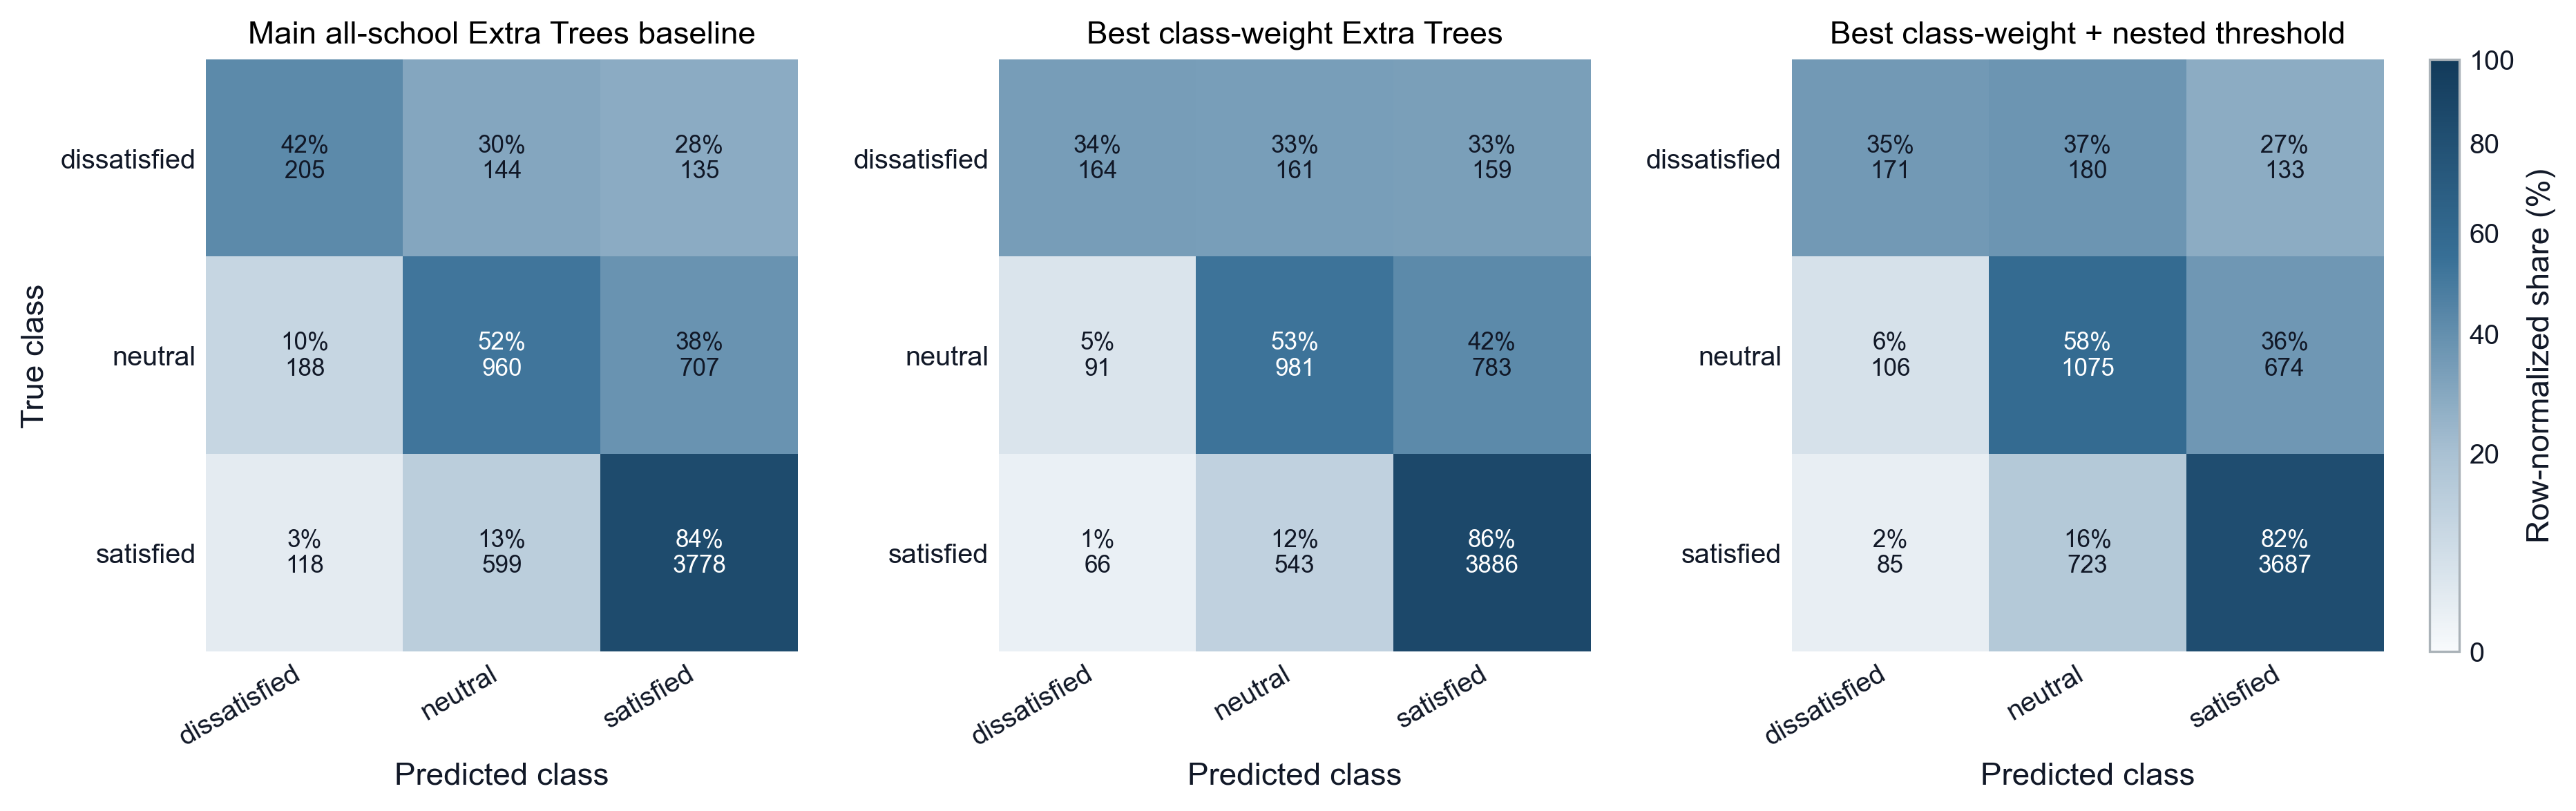

In [15]:
def confusion_matrix_for_predictions(predictions: pd.DataFrame, variant: str) -> pd.DataFrame:
    selected = predictions[predictions["variant"].eq(variant)].copy()
    return pd.DataFrame(
        confusion_matrix(selected["y_true"], selected["y_pred"], labels=CLASS_ORDER),
        index=CLASS_ORDER,
        columns=CLASS_ORDER,
    )


baseline_class_weight_variant = "class_weight_balanced"
class_weight_best_predictions = class_weight_predictions[
    class_weight_predictions["variant"].eq(best_class_weight_variant)
].copy()

class_weight_threshold_predictions = pd.concat(
    [
        class_weight_predictions[
            class_weight_predictions["variant"].isin([baseline_class_weight_variant, best_class_weight_variant])
        ],
        threshold_predictions,
    ],
    ignore_index=True,
    sort=False,
)

confusion_variants = [
    ("Main all-school Extra Trees baseline", baseline_class_weight_variant),
    ("Best class-weight Extra Trees", best_class_weight_variant),
    ("Best class-weight + nested threshold", "best_class_weight_nested_threshold"),
]

confusion_tables = []
for label, variant in confusion_variants:
    matrix = confusion_matrix_for_predictions(class_weight_threshold_predictions, variant)
    long_matrix = matrix.reset_index(names="true_class").melt(
        id_vars="true_class",
        var_name="predicted_class",
        value_name="count",
    )
    long_matrix.insert(0, "label", label)
    long_matrix.insert(1, "variant", variant)
    confusion_tables.append(long_matrix)

class_weight_threshold_confusions = pd.concat(confusion_tables, ignore_index=True)


fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), constrained_layout=True)
confusion_matrices = [
    confusion_matrix_for_predictions(class_weight_threshold_predictions, variant)
    for _, variant in confusion_variants
]
image = None
for ax, (label, _), matrix in zip(axes, confusion_variants, confusion_matrices):
    image, colorbar_label = plot_confusion_matrix(
        ax,
        matrix,
        labels=CLASS_ORDER,
        display_labels=CLASS_ORDER,
        title=label,
        xtick_rotation=30,
        annotation_fontsize=8.4,
    )
for ax in axes[1:]:
    ax.set_ylabel("")
fig.colorbar(image, ax=axes, fraction=0.025, pad=0.02, label=colorbar_label)

class_weight_folds_path = OUTPUT_DIR / "ieq_class_weight_search_folds.csv"
class_weight_summary_path = OUTPUT_DIR / "ieq_class_weight_search_summary.csv"
class_weight_predictions_path = OUTPUT_DIR / "ieq_class_weight_search_predictions.csv"
threshold_folds_path = OUTPUT_DIR / "ieq_class_weight_threshold_folds.csv"
threshold_grid_path = OUTPUT_DIR / "ieq_class_weight_threshold_inner_grid.csv"
threshold_predictions_path = OUTPUT_DIR / "ieq_class_weight_threshold_predictions.csv"
threshold_comparison_path = OUTPUT_DIR / "ieq_class_weight_threshold_comparison.csv"
threshold_confusions_path = OUTPUT_DIR / "ieq_class_weight_threshold_confusion_matrices.csv"
threshold_figure_path = FIGURE_DIR / "ieq_class_weight_threshold_confusion_matrices.png"

class_weight_folds.to_csv(class_weight_folds_path, index=False)
class_weight_summary.to_csv(class_weight_summary_path, index=False)
class_weight_predictions.to_csv(class_weight_predictions_path, index=False)
class_weight_threshold_folds.to_csv(threshold_folds_path, index=False)
threshold_grid_results.to_csv(threshold_grid_path, index=False)
threshold_predictions.to_csv(threshold_predictions_path, index=False)
threshold_display.to_csv(threshold_comparison_path, index=False)
class_weight_threshold_confusions.to_csv(threshold_confusions_path, index=False)
fig.savefig(threshold_figure_path, dpi=300, bbox_inches="tight")

print("Saved class-weight folds to:", class_weight_folds_path)
print("Saved class-weight summary to:", class_weight_summary_path)
print("Saved class-weight predictions to:", class_weight_predictions_path)
print("Saved nested threshold folds to:", threshold_folds_path)
print("Saved nested threshold inner-grid results to:", threshold_grid_path)
print("Saved nested threshold predictions to:", threshold_predictions_path)
print("Saved comparison table to:", threshold_comparison_path)
print("Saved confusion matrices to:", threshold_confusions_path)
print("Saved confusion-matrix figure to:", threshold_figure_path)
plt.show()


## 7. Complete-Case Checks

These checks restrict the evaluation to rows where selected sensor values were originally observed. They test whether missingness and imputation are hiding a stronger model on cleaner rows.

Decision: <span style="color:#B42318; font-weight:700">REJECTED</span> as final-model replacements because they change the evaluated population and discard rows.


In [16]:
complete_main_sensor_mask = clean_data[["Temperature", "RH", "CO2", "Lighting", "Sound"]].notna().all(axis=1)
complete_lighting_sound_ttrend_mask = clean_data[["Lighting", "Sound", "Ttrend"]].notna().all(axis=1)

complete_case_specs = [
    (
        "complete_main_ieq_sensors",
        complete_main_sensor_mask,
        "Rows with originally observed Temperature, RH, CO2, Lighting, and Sound.",
    ),
    (
        "complete_lighting_sound_ttrend",
        complete_lighting_sound_ttrend_mask,
        "Rows with originally observed Lighting, Sound, and Ttrend.",
    ),
]

complete_case_folds = []
for variant, mask, note in complete_case_specs:
    X_filtered = X_base.loc[mask].reset_index(drop=True)
    y_filtered = y.loc[mask].reset_index(drop=True)
    print(variant, "rows:", len(y_filtered))
    complete_case_folds.append(
        evaluate_cv_variant(
            "complete_case_filter",
            variant,
            X_filtered,
            y_filtered,
            note=note,
        )
    )

complete_case_folds = pd.concat(complete_case_folds, ignore_index=True)

display(
    result_table(
        summarize_folds(complete_case_folds)
        .sort_values("macro_f1_mean", ascending=False)
    )
)
print("Change relative to main Extra Trees baseline")
display(
    metric_change_table(
        summarize_folds(complete_case_folds).sort_values("macro_f1_mean", ascending=False),
        baseline_summary,
    )
)

complete_main_ieq_sensors rows: 5349


complete_lighting_sound_ttrend rows: 2314


,variant,cv_splits,rows,predictors,macro_f1_mean,accuracy_mean,balanced_accuracy_mean,ordinal_mae_mean
1,complete_main_ieq_sensors,5,5349,20,0.605892,0.720884,0.608889,0.315758
0,complete_lighting_sound_ttrend,5,2314,20,0.601434,0.701810,0.603211,0.331893


Change relative to main Extra Trees baseline


,variant,same_population_as_main,macro_f1_delta,accuracy_delta,balanced_accuracy_delta,ordinal_mae_delta
0,complete_main_ieq_sensors,False,0.013578,-0.002411,0.015132,0.002033
1,complete_lighting_sound_ttrend,False,0.009120,-0.021484,0.009454,0.018167


## 8. Train-Fold Class Balancing

These variants change only the training folds by duplicating or interpolating minority-class rows. The validation folds remain untouched, so the reported metrics still use real held-out observations.

Decision: <span style="color:#B42318; font-weight:700">REJECTED</span>. The class-balancing variants are kept as sensitivity checks but not used in the final optimized model.


In [17]:
CONTINUOUS_SYNTHETIC_COLUMNS = [
    "Temperature",
    "RH",
    "CLO",
    "CO2",
    "Lighting",
    "Sound",
    "Age",
    "EA",
    "Ttrend",
    "Vote hour",
]


def target_count_for_class(y_train: pd.Series, class_label: str, fraction_of_majority: float) -> int:
    counts = y_train.value_counts()
    majority_count = int(counts.max())
    current_count = int(counts.get(class_label, 0))
    return max(current_count, int(np.ceil(majority_count * fraction_of_majority)))


def random_oversample_to_fraction(fraction_of_majority: float) -> SamplingFunction:
    def sampler(X_train: pd.DataFrame, y_train: pd.Series, fold: int) -> tuple[pd.DataFrame, pd.Series]:
        rng = np.random.default_rng(SEED + fold * 100)
        X_parts = [X_train]
        y_parts = [y_train]

        for class_label in CLASS_ORDER:
            class_indices = np.flatnonzero(y_train.to_numpy() == class_label)
            if len(class_indices) == 0:
                continue
            target_count = target_count_for_class(y_train, class_label, fraction_of_majority)
            add_count = target_count - len(class_indices)
            if add_count <= 0:
                continue
            chosen_positions = rng.choice(class_indices, size=add_count, replace=True)
            X_parts.append(X_train.iloc[chosen_positions].copy())
            y_parts.append(y_train.iloc[chosen_positions].copy())

        return pd.concat(X_parts, ignore_index=True), pd.concat(y_parts, ignore_index=True)

    return sampler


def synthetic_interpolate_to_fraction(fraction_of_majority: float) -> SamplingFunction:
    def sampler(X_train: pd.DataFrame, y_train: pd.Series, fold: int) -> tuple[pd.DataFrame, pd.Series]:
        rng = np.random.default_rng(SEED + fold * 1000)
        synthetic_rows = []
        synthetic_labels = []
        continuous_columns = [column for column in CONTINUOUS_SYNTHETIC_COLUMNS if column in X_train.columns]

        for class_label in CLASS_ORDER:
            class_positions = np.flatnonzero(y_train.to_numpy() == class_label)
            if len(class_positions) < 2:
                continue
            target_count = target_count_for_class(y_train, class_label, fraction_of_majority)
            add_count = target_count - len(class_positions)
            if add_count <= 0:
                continue

            first_positions = rng.choice(class_positions, size=add_count, replace=True)
            second_positions = rng.choice(class_positions, size=add_count, replace=True)
            alpha = rng.random(add_count)

            first_rows = X_train.iloc[first_positions].reset_index(drop=True)
            second_rows = X_train.iloc[second_positions].reset_index(drop=True)
            generated = first_rows.copy()

            for column in continuous_columns:
                generated[column] = first_rows[column].to_numpy() + alpha * (
                    second_rows[column].to_numpy() - first_rows[column].to_numpy()
                )

            non_continuous = [column for column in X_train.columns if column not in continuous_columns]
            for column in non_continuous:
                choose_second = rng.random(add_count) < 0.5
                generated.loc[choose_second, column] = second_rows.loc[choose_second, column].to_numpy()

            synthetic_rows.append(generated)
            synthetic_labels.extend([class_label] * add_count)

        if not synthetic_rows:
            return X_train.copy(), y_train.copy()

        X_augmented = pd.concat([X_train, *synthetic_rows], ignore_index=True)
        y_augmented = pd.concat([y_train.reset_index(drop=True), pd.Series(synthetic_labels)], ignore_index=True)
        return X_augmented, y_augmented

    return sampler

In [18]:
sampling_folds = pd.DataFrame()

if RUN_SYNTHETIC_SAMPLING:
    sampling_specs = [
        (
            "random_oversample_to_50pct_majority",
            random_oversample_to_fraction(0.50),
            "Randomly duplicates minority-class training records up to 50 percent of the majority-class count.",
        ),
        (
            "synthetic_interpolate_to_50pct_majority",
            synthetic_interpolate_to_fraction(0.50),
            "Creates fold-internal synthetic minority-class training rows up to 50 percent of the majority-class count.",
        ),
        (
            "synthetic_interpolate_to_majority",
            synthetic_interpolate_to_fraction(1.00),
            "Creates fold-internal synthetic minority-class training rows up to the majority-class count.",
        ),
    ]

    sampling_folds = pd.concat(
        [
            evaluate_cv_variant(
                "train_fold_class_balancing",
                variant,
                X_base,
                y,
                sampling_fn=sampler,
                note=note,
            )
            for variant, sampler, note in sampling_specs
        ],
        ignore_index=True,
    )

    display(
        result_table(
            summarize_folds(sampling_folds)
            .sort_values("macro_f1_mean", ascending=False)
        ).merge(
            summarize_folds(sampling_folds)[["variant", "train_rows_after_sampling_mean"]],
            on="variant",
            how="left",
        )
    )
    print("Change relative to main Extra Trees baseline")
    display(
        metric_change_table(
            summarize_folds(sampling_folds).sort_values("macro_f1_mean", ascending=False),
            baseline_summary,
        )
    )
else:
    print("Synthetic sampling experiments skipped because RUN_SYNTHETIC_SAMPLING is False.")

,variant,cv_splits,rows,predictors,macro_f1_mean,accuracy_mean,balanced_accuracy_mean,ordinal_mae_mean,train_rows_after_sampling_mean
0,synthetic_interpolate_to_50pct_majority,5,6834,20,0.595176,0.717296,0.608736,0.327040,7192.0
1,random_oversample_to_50pct_majority,5,6834,20,0.591093,0.716563,0.600114,0.324847,7192.0
2,synthetic_interpolate_to_majority,5,6834,20,0.586859,0.716419,0.598152,0.330403,10788.0


Change relative to main Extra Trees baseline


,variant,same_population_as_main,macro_f1_delta,accuracy_delta,balanced_accuracy_delta,ordinal_mae_delta
0,synthetic_interpolate_to_50pct_majority,True,0.002862,-0.005999,0.014979,0.013315
1,random_oversample_to_50pct_majority,True,-0.001221,-0.006731,0.006358,0.011122
2,synthetic_interpolate_to_majority,True,-0.005455,-0.006875,0.004395,0.016678


## 9. Ten-Fold Sensitivity Check

The main notebook uses five-fold cross-validation. This section reruns the baseline and the retained imputation-indicator variant with ten folds to check whether the conclusion is stable under a different fold count.

Decision: <span style="color:#0F7B5F; font-weight:700">APPLIED</span> as validation evidence for the retained imputation-indicator workflow; it is not a separate feature change.


In [19]:
ten_fold_folds = pd.DataFrame()
ten_fold_summary = pd.DataFrame()
ten_fold_article_table = pd.DataFrame()

if RUN_TEN_FOLD_VALIDATION:
    ten_fold_baseline_folds = evaluate_cv_variant(
        "ten_fold_validation",
        "main_all_school_extra_trees_10fold",
        X_base,
        y,
        note="Ten-fold sensitivity check for the tuned Extra Trees baseline.",
        n_splits=TEN_FOLD_SPLITS,
    )

    ten_fold_missingness_folds = evaluate_cv_variant(
        "ten_fold_validation",
        "imputation_indicators_10fold",
        X_missingness,
        y,
        note="Ten-fold sensitivity check for Extra Trees with imputation indicators.",
        n_splits=TEN_FOLD_SPLITS,
    )

    ten_fold_folds = pd.concat([ten_fold_baseline_folds, ten_fold_missingness_folds], ignore_index=True)
    ten_fold_summary = summarize_folds(ten_fold_folds)

    ten_fold_baseline = ten_fold_summary[
        ten_fold_summary["variant"].eq("main_all_school_extra_trees_10fold")
    ].iloc[0]

    for metric in REPORT_METRICS:
        ten_fold_summary[f"{metric}_delta_vs_10fold_baseline"] = (
            ten_fold_summary[f"{metric}_mean"] - ten_fold_baseline[f"{metric}_mean"]
        )

    ten_fold_summary["same_population_as_10fold_baseline"] = ten_fold_summary["rows"].eq(
        int(ten_fold_baseline["rows"])
    )

    ten_fold_article_columns = [
        "experiment",
        "variant",
        "cv_splits",
        "rows",
        "predictors",
        "same_population_as_10fold_baseline",
        "macro_f1_mean",
        "macro_f1_delta_vs_10fold_baseline",
        "accuracy_mean",
        "accuracy_delta_vs_10fold_baseline",
        "balanced_accuracy_mean",
        "balanced_accuracy_delta_vs_10fold_baseline",
        "ordinal_mae_mean",
        "ordinal_mae_delta_vs_10fold_baseline",
        "note",
    ]
    ten_fold_article_table = ten_fold_summary[ten_fold_article_columns].copy()

    for column in ten_fold_article_table.select_dtypes(include=["float"]).columns:
        ten_fold_article_table[column] = ten_fold_article_table[column].round(6)

    print("Ten-fold metric values")
    display(result_table(ten_fold_summary))
    print("Change relative to ten-fold Extra Trees baseline")
    display(
        metric_change_table(
            ten_fold_summary[
                ten_fold_summary["variant"].ne("main_all_school_extra_trees_10fold")
            ],
            ten_fold_summary,
            baseline_variant="main_all_school_extra_trees_10fold",
        )
    )
    display(ten_fold_article_table)

    ten_fold_folds_path = OUTPUT_DIR / "ieq_extra_trees_10fold_validation_folds.csv"
    ten_fold_summary_path = OUTPUT_DIR / "ieq_extra_trees_10fold_validation_summary.csv"
    ten_fold_article_path = OUTPUT_DIR / "ieq_extra_trees_10fold_validation_article_table.csv"

    ten_fold_folds.to_csv(ten_fold_folds_path, index=False)
    ten_fold_summary.to_csv(ten_fold_summary_path, index=False)
    ten_fold_article_table.to_csv(ten_fold_article_path, index=False)

    print("Saved ten-fold fold-level results to:", ten_fold_folds_path)
    print("Saved ten-fold summary to:", ten_fold_summary_path)
    print("Saved ten-fold article table to:", ten_fold_article_path)
else:
    print("Ten-fold validation skipped because RUN_TEN_FOLD_VALIDATION is False.")
    

Ten-fold metric values


,variant,cv_splits,rows,predictors,macro_f1_mean,accuracy_mean,balanced_accuracy_mean,ordinal_mae_mean
0,imputation_indicators_10fold,10,6834,31,0.608130,0.732656,0.612235,0.303193
1,main_all_school_extra_trees_10fold,10,6834,20,0.595741,0.724461,0.597708,0.312852


Change relative to ten-fold Extra Trees baseline


,variant,same_population_as_main,macro_f1_delta,accuracy_delta,balanced_accuracy_delta,ordinal_mae_delta
0,imputation_indicators_10fold,True,0.012389,0.008195,0.014527,-0.009659


,experiment,variant,cv_splits,rows,predictors,same_population_as_10fold_baseline,macro_f1_mean,macro_f1_delta_vs_10fold_baseline,accuracy_mean,accuracy_delta_vs_10fold_baseline,balanced_accuracy_mean,balanced_accuracy_delta_vs_10fold_baseline,ordinal_mae_mean,ordinal_mae_delta_vs_10fold_baseline,note
0,ten_fold_validation,imputation_indicators_10fold,10,6834,31,True,0.608130,0.012389,0.732656,0.008195,0.612235,0.014527,0.303193,-0.009659,Ten-fold sensitivity check for Extra Trees wit...
1,ten_fold_validation,main_all_school_extra_trees_10fold,10,6834,20,True,0.595741,0.000000,0.724461,0.000000,0.597708,0.000000,0.312852,0.000000,Ten-fold sensitivity check for the tuned Extra...


Saved ten-fold fold-level results to: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\supplementary_experiments\tables\ieq_extra_trees_10fold_validation_folds.csv
Saved ten-fold summary to: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\supplementary_experiments\tables\ieq_extra_trees_10fold_validation_summary.csv
Saved ten-fold article table to: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\supplementary_experiments\tables\ieq_extra_trees_10fold_validation_article_table.csv


## 10. Fine-Tuning Summary

This final table is formatted for the paper. The first row gives the absolute cross-validated performance of the main all-school Extra Trees baseline. Every later row gives the change relative to that same baseline, so positive values mean improvement for F1, accuracy, and balanced accuracy, while negative values mean improvement for ordinal MAE.

The rows intentionally follow the article order rather than sorting by score. Screens that tested many variants contribute only the best row from that method.


In [20]:
fold_tables = [
    baseline_folds,
    threshold_folds,
    missingness_folds,
    soft_vote_folds,
    ordinal_folds,
    class_weight_folds,
    class_weight_threshold_folds,
    complete_case_folds,
]
if not sampling_folds.empty:
    fold_tables.append(sampling_folds)
if not ten_fold_folds.empty:
    fold_tables.append(ten_fold_folds)

fine_tuning_folds = pd.concat([table for table in fold_tables if not table.empty], ignore_index=True)
full_fine_tuning_summary = summarize_folds(fine_tuning_folds)

baseline_row = full_fine_tuning_summary[full_fine_tuning_summary["variant"].eq("main_all_school_extra_trees")].iloc[0]

for metric in REPORT_METRICS:
    full_fine_tuning_summary[f"{metric}_delta_vs_main"] = full_fine_tuning_summary[f"{metric}_mean"] - baseline_row[f"{metric}_mean"]

full_fine_tuning_summary["same_population_as_main"] = full_fine_tuning_summary["rows"].eq(int(baseline_row["rows"]))
full_fine_tuning_summary = add_decision_columns(full_fine_tuning_summary)


def get_variant_row(variant: str) -> pd.Series:
    rows = full_fine_tuning_summary[full_fine_tuning_summary["variant"].eq(variant)]
    if rows.empty:
        raise ValueError(f"Missing expected final-summary variant: {variant}")
    return rows.iloc[0]


def get_best_variant_row(variants: list[str]) -> pd.Series:
    rows = full_fine_tuning_summary[full_fine_tuning_summary["variant"].isin(variants)].copy()
    if rows.empty:
        raise ValueError(f"No variants found from expected set: {variants}")
    return rows.sort_values(["macro_f1_mean", "accuracy_mean"], ascending=[False, False]).iloc[0]


def get_best_soft_vote_row() -> pd.Series:
    rows = full_fine_tuning_summary[full_fine_tuning_summary["variant"].str.startswith("soft_vote_et_")].copy()
    if rows.empty:
        raise ValueError("No soft-vote rows found for final summary.")
    return rows.sort_values(["macro_f1_mean", "accuracy_mean"], ascending=[False, False]).iloc[0]


def soft_vote_label(variant: str) -> str:
    weights = variant.replace("soft_vote_et_", "").split("_rf_")
    if len(weights) != 2:
        return "Soft-vote ET + RF"
    return f"Soft-vote ET {float(weights[0]):.2f} + RF {float(weights[1]):.2f}"


def format_absolute(value: float) -> str:
    return f"{value:.3f}"


def format_delta(value: float) -> str:
    return "0.000" if abs(value) < 0.0005 else f"{value:+.3f}"


def numeric_row(experiment: str, row: pd.Series, *, baseline: bool = False) -> dict[str, float | str | bool]:
    if baseline:
        return {
            "Experiment": experiment,
            "Macro F1": row["macro_f1_mean"],
            "Accuracy": row["accuracy_mean"],
            "Bal. acc.": row["balanced_accuracy_mean"],
            "Ordinal MAE": row["ordinal_mae_mean"],
            "is_baseline": True,
            "variant": row["variant"],
        }
    return {
        "Experiment": experiment,
        "Macro F1": row["macro_f1_delta_vs_main"],
        "Accuracy": row["accuracy_delta_vs_main"],
        "Bal. acc.": row["balanced_accuracy_delta_vs_main"],
        "Ordinal MAE": row["ordinal_mae_delta_vs_main"],
        "is_baseline": False,
        "variant": row["variant"],
    }


class_weight_variants = [
    "class_weight_balanced",
    "class_weight_equal_1_1_1",
    "class_weight_dissatisfied_2_neutral_1_5",
    "class_weight_dissatisfied_3_neutral_2",
    "class_weight_dissatisfied_4_neutral_2",
    "class_weight_dissatisfied_5_neutral_2",
    "class_weight_stronger_dissatisfied",
    "class_weight_stronger_neutral",
    "class_weight_stronger_dissatisfied_neutral",
]
sampling_variants = [
    "random_oversample_to_50pct_majority",
    "synthetic_interpolate_to_50pct_majority",
    "synthetic_interpolate_to_majority",
]

soft_vote_article_row = get_variant_row("soft_vote_et_0.80_rf_0.20")
final_summary_numeric = pd.DataFrame(
    [
        numeric_row("Main all-school Extra Trees baseline", baseline_row, baseline=True),
        numeric_row("Threshold T/CO2 feature engineering", get_variant_row("threshold_flags_co2_1000_t18_t24")),
        numeric_row("Imputation-indicator columns", get_variant_row("imputation_indicators")),
        numeric_row("Soft-vote ET 0.80 + RF 0.20", soft_vote_article_row),
        numeric_row("Ordinal Extra Trees decomposition", get_variant_row("ordinal_extra_trees_decomposition")),
        numeric_row("Ordinal Random Forest decomposition", get_variant_row("ordinal_random_forest_decomposition")),
        numeric_row("Best class-weight Extra Trees", get_best_variant_row(class_weight_variants)),
        numeric_row("Best class-weight + nested threshold", get_variant_row("best_class_weight_nested_threshold")),
        numeric_row("Main-sensor complete-case filter", get_variant_row("complete_main_ieq_sensors")),
        numeric_row("Lighting + Sound + Ttrend complete-case filter", get_variant_row("complete_lighting_sound_ttrend")),
        numeric_row("Best synthetic sampling screen", get_best_variant_row(sampling_variants)),
        numeric_row("Ten-fold validation check", get_variant_row("main_all_school_extra_trees_10fold")),
    ]
)

final_summary_table = final_summary_numeric.copy()
for metric in ["Macro F1", "Accuracy", "Bal. acc.", "Ordinal MAE"]:
    final_summary_table[metric] = [
        format_absolute(value) if is_baseline else format_delta(value)
        for value, is_baseline in zip(final_summary_numeric[metric], final_summary_numeric["is_baseline"])
    ]

final_summary_table = final_summary_table[["Experiment", "Macro F1", "Accuracy", "Bal. acc.", "Ordinal MAE"]]
fine_tuning_summary = final_summary_numeric.copy()
article_table = final_summary_table.copy()

print("Table 3: Extra Trees optimization summary.")
display(article_table)


Table 3: Extra Trees optimization summary.


,Experiment,Macro F1,Accuracy,Bal. acc.,Ordinal MAE
0,Main all-school Extra Trees baseline,0.592,0.723,0.594,0.314
1,Threshold T/CO2 feature engineering,-0.006,-0.005,-0.006,+0.006
2,Imputation-indicator columns,+0.012,+0.007,+0.012,-0.007
3,Soft-vote ET 0.80 + RF 0.20,+0.002,+0.001,+0.001,0.000
4,Ordinal Extra Trees decomposition,-0.006,+0.007,-0.008,-0.003
5,Ordinal Random Forest decomposition,-0.044,-0.011,-0.040,+0.023
6,Best class-weight Extra Trees,+0.005,+0.013,-0.016,-0.017
7,Best class-weight + nested threshold,+0.002,-0.001,-0.009,-0.004
8,Main-sensor complete-case filter,+0.014,-0.002,+0.015,+0.002
9,Lighting + Sound + Ttrend complete-case filter,+0.009,-0.021,+0.009,+0.018


In [21]:
folds_path = OUTPUT_DIR / "ieq_extra_trees_fine_tuning_folds.csv"
full_summary_path = OUTPUT_DIR / "ieq_extra_trees_fine_tuning_full_summary.csv"
summary_path = OUTPUT_DIR / "ieq_extra_trees_fine_tuning_summary_numeric.csv"
article_table_path = OUTPUT_DIR / "ieq_extra_trees_fine_tuning_article_table.csv"

fine_tuning_folds.to_csv(folds_path, index=False)
full_fine_tuning_summary.to_csv(full_summary_path, index=False)
fine_tuning_summary.to_csv(summary_path, index=False)
article_table.to_csv(article_table_path, index=False)

print("Saved fold-level results to:", folds_path)
print("Saved full variant summary to:", full_summary_path)
print("Saved numeric final summary to:", summary_path)
print("Saved formatted article table to:", article_table_path)


Saved fold-level results to: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\supplementary_experiments\tables\ieq_extra_trees_fine_tuning_folds.csv
Saved full variant summary to: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\supplementary_experiments\tables\ieq_extra_trees_fine_tuning_full_summary.csv
Saved numeric final summary to: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\supplementary_experiments\tables\ieq_extra_trees_fine_tuning_summary_numeric.csv
Saved formatted article table to: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\supplementary_experiments\tables\ieq_extra_trees_fine_tuning_article_table.csv
